In [ ]:
!pip install optuna wandb ray[tune]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 MB 31.9 MB/s eta 0:00:00


In [ ]:
!pip install transformers datasets torch torchvision pillow pytesseract evaluate seqeval peft

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.0 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=7781c85af6a05a4969048ce7bf564667d5f05f0b0aebbe775f83bebe97ef9772
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
import os
import json
import torch
import numpy as np
import evaluate
from PIL import Image
from datasets import Dataset, DatasetDict
from transformers import (
    AutoProcessor,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DefaultDataCollator
)

In [ ]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATASET_DIR = "./sroie-datasetv2/SROIE2019"
MODEL_ID = "microsoft/layoutlmv3-base"
OUTPUT_DIR = "./layoutlmv3-sroie-model"

# Flat labels based on your JSON structure
LABELS = ["O", "COMPANY", "DATE", "ADDRESS", "TOTAL"]
LABEL2ID = {label: idx for idx, label in enumerate(LABELS)}
ID2LABEL = {idx: label for idx, label in enumerate(LABELS)}

In [ ]:
# ==========================================
# 2. THE RAM-FRIENDLY DATA PARSER
# ==========================================
def normalize_bbox(box, width, height):
    return [
        max(0, min(1000, int(1000 * (box[0] / width)))),
        max(0, min(1000, int(1000 * (box[1] / height)))),
        max(0, min(1000, int(1000 * (box[2] / width)))),
        max(0, min(1000, int(1000 * (box[3] / height)))),
    ]

def load_sroie_split(split_name):
    split_dir = os.path.join(DATASET_DIR, split_name)
    img_dir, box_dir, ent_dir = [os.path.join(split_dir, f) for f in ["img", "box", "entities"]]

    examples = {"image_path": [], "words": [], "bboxes": [], "ner_tags": []}

    for filename in os.listdir(img_dir):
        if not filename.endswith(".jpg"): continue
        file_id = filename.split(".")[0]

        img_path = os.path.join(img_dir, filename)
        box_path = os.path.join(box_dir, file_id + ".txt")
        ent_path = os.path.join(ent_dir, file_id + ".txt")

        if not (os.path.exists(box_path) and os.path.exists(ent_path)): continue

        try:
            with Image.open(img_path) as img:
                width, height = img.size

            # ADDED: errors='ignore' to bypass weird characters like the Pound sign (£)
            with open(ent_path, 'r', encoding='utf-8', errors='ignore') as f:
                entities = json.load(f)
                # print(entities)
        except Exception:
            continue

        words, bboxes, ner_tags = [], [], []

        # ADDED: errors='ignore' here as well
        with open(box_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                parts = line.strip().split(',')
                if len(parts) < 9: continue

                coords = [int(p) for p in parts[:8]]
                text_fragment = ",".join(parts[8:]).strip()

                x_min = min(coords[0], coords[2], coords[4], coords[6])
                y_min = min(coords[1], coords[3], coords[5], coords[7])
                x_max = max(coords[0], coords[2], coords[4], coords[6])
                y_max = max(coords[1], coords[3], coords[5], coords[7])

                if x_max <= x_min or y_max <= y_min: continue

                assigned_label = "O"
                for key, full_string in entities.items():
                    if full_string and text_fragment in full_string:
                        assigned_label = key.upper()
                        break

                words.append(text_fragment)
                bboxes.append(normalize_bbox([x_min, y_min, x_max, y_max], width, height))
                ner_tags.append(LABEL2ID[assigned_label])

        examples["image_path"].append(img_path)
        examples["words"].append(words)
        examples["bboxes"].append(bboxes)
        examples["ner_tags"].append(ner_tags)

    return Dataset.from_dict(examples)

In [ ]:
# ==========================================
# 3. INITIALIZATION & PREPROCESSING (OOM SAFE)
# ==========================================
print("Loading and parsing raw data...")
raw_datasets = DatasetDict({
    "train": load_sroie_split("train"),
    "test": load_sroie_split("test")
})

Loading and parsing raw data...


In [ ]:


processor = AutoProcessor.from_pretrained(MODEL_ID, apply_ocr=False)
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_ID, id2label=ID2LABEL, label2id=LABEL2ID, num_labels=len(LABELS)
)

def prepare_dataset(batch):
    # Open images on the fly during the mapping process
    images = [Image.open(path).convert("RGB") for path in batch["image_path"]]

    # REMOVED: return_tensors="pt". This forces it to output lightweight lists instead of heavy tensors.
    encoding = processor(
        images,
        batch["words"],
        boxes=batch["bboxes"],
        word_labels=batch["ner_tags"],
        truncation=True,
        padding="max_length",
        max_length=512
    )
    return encoding

print("Tokenizing data (Optimized for low RAM)...")
encoded_datasets = raw_datasets.map(
    prepare_dataset,
    batched=True,
    batch_size=8, # Keep this low!
    # writer_batch_size=2, # Forces Dataset to write to disk frequently rather than holding in RAM
    remove_columns=raw_datasets["train"].column_names
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.bias                    | MISSING    | 
classifier.weight                  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizing data (Optimized for low RAM)...


Map:   0%|          | 0/626 [00:00<?, ? examples/s]

Map:   0%|          | 0/347 [00:00<?, ? examples/s]

In [ ]:
from collections import Counter

unique_labels = Counter(label for sublist in encoded_datasets['train']['labels'] for label in sublist)
print(unique_labels)

Counter({-100: 286972, 0: 27712, 3: 1844, 2: 1677, 4: 1576, 1: 731})


In [ ]:
# metric = evaluate.load("seqeval")

# def compute_metrics(p):
#     predictions, labels = p
#     predictions = np.argmax(predictions, axis=2)

#     true_predictions = [
#         [ID2LABEL[p] for (p, l) in zip(prediction, label) if l != -100]
#         for prediction, label in zip(predictions, labels)
#     ]
#     true_labels = [
#         [ID2LABEL[l] for (p, l) in zip(prediction, label) if l != -100]
#         for prediction, label in zip(predictions, labels)
#     ]

#     results = metric.compute(predictions=true_predictions, references=true_labels)

#     # --- Macro F1: simple average of per-class F1 scores (ignores class size) ---
#     per_class_f1 = [results[cls]["f1"] for cls in results if isinstance(results[cls], dict)]
#     macro_f1 = np.mean(per_class_f1)

#     # --- Micro F1: recompute from summed TP/FP/FN across all classes ---
#     total_tp = sum(results[cls]["number"] * results[cls]["recall"] for cls in results if isinstance(results[cls], dict))
#     total_predicted = sum(
#         (results[cls]["number"] * results[cls]["recall"]) / results[cls]["precision"]
#         for cls in results if isinstance(results[cls], dict) and results[cls]["precision"] > 0
#     )
#     total_actual = sum(results[cls]["number"] for cls in results if isinstance(results[cls], dict))

#     micro_precision = total_tp / total_predicted if total_predicted > 0 else 0
#     micro_recall = total_tp / total_actual if total_actual > 0 else 0
#     micro_f1 = (2 * micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0

#     return {
#         "precision": results["overall_precision"],
#         "recall": results["overall_recall"],
#         "f1": results["overall_f1"],
#         "accuracy": results["overall_accuracy"],
#         "f1_macro": macro_f1,
#         "f1_micro": micro_f1,
#     }

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        p for prediction, label in zip(predictions, labels)
        for p, l in zip(prediction, label) if l != -100
    ]
    true_labels = [
        l for prediction, label in zip(predictions, labels)
        for p, l in zip(prediction, label) if l != -100
    ]

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, true_predictions, average="weighted", zero_division=0
    )
    acc = accuracy_score(true_labels, true_predictions)

    _, _, f1_per_class, _ = precision_recall_fscore_support(
        true_labels, true_predictions, average=None, zero_division=0
    )
    macro_f1 = np.mean(f1_per_class)

    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
        true_labels, true_predictions, average="micro", zero_division=0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": acc,
        "f1_macro": macro_f1,
        "f1_micro": micro_f1,
    }

In [ ]:
import math
import gc


# ==========================================
# 4. TRAINING
# ==========================================

# --- Cleanup before training ---

print(f"Free VRAM before training: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# # --- Helper Functions ---
# def model_init(trial):
#     return AutoModelForTokenClassification.from_pretrained(
#         MODEL_ID,
#         id2label=ID2LABEL,
#         label2id=LABEL2ID,
#         num_labels=len(LABELS),
#     )

# def optuna_hp_space(trial):
#     return {
#         # Learning rate — tighter, stable range for LayoutLMv3
#         "learning_rate": trial.suggest_float("learning_rate", 5e-6, 5e-5, log=True),

#         # Batch size — you have ~73GB free, push it
#         "per_device_train_batch_size": trial.suggest_categorical(
#             "per_device_train_batch_size", [4, 8, 16]
#         ),

#         # Gradient accumulation — pair with batch size
#         "gradient_accumulation_steps": trial.suggest_categorical(
#             "gradient_accumulation_steps", [1, 2, 4]
#         ),

#         # Warmup ratio — scales properly across LR/batch combos
#         "warmup_ratio": trial.suggest_float("warmup_ratio", 0.05, 0.2),

#         # Weight decay — regularization sweep
#         "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1),

#         # Adam epsilon — numerical stability
#         "adam_epsilon": trial.suggest_categorical(
#             "adam_epsilon", [1e-8, 1e-6]
#         ),

#         # Scheduler
#         "lr_scheduler_type": trial.suggest_categorical(
#             "lr_scheduler_type", ["linear", "cosine", "cosine_with_restarts"]
#         ),
#     }

# def compute_objective(metrics: dict) -> tuple:
#     loss = metrics.get("eval_loss", float("inf"))   # Objective 1 (minimize)
#     f1   = metrics.get("eval_f1", 0.0)              # Objective 2 (maximize)
#     return (loss, f1)

# --- Training Arguments ---
# NOTE: per_device_train_batch_size / gradient_accumulation_steps / warmup_ratio /
#       weight_decay / lr_scheduler_type will be OVERRIDDEN by Optuna each trial.
#       The values below are just safe defaults.
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=10,

    # Defaults — Optuna overrides these
    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,        # Eval has no grad → can be larger
    gradient_accumulation_steps=2,

    # Memory / precision
    # fp16=True,
    # gradient_checkpointing=True,       # LayoutLMv3 doesn't support this

    # Optimizer
    optim="adamw_torch",
    adam_beta1=0.9,
    adam_beta2=0.999,
    adam_epsilon=1e-8,                   # Optuna will override
    weight_decay=0.01,                   # Optuna will override

    # Scheduler
    lr_scheduler_type="linear",          # Optuna will override
    learning_rate=2e-5,                  # Optuna will override
    warmup_ratio=0.1,                    # Optuna will override (replaces warmup_steps)

    # Eval & Checkpointing
    eval_strategy="steps",
    eval_steps=math.ceil(79 / 3),
    save_strategy="steps",
    save_steps=math.ceil(79 / 3),
    logging_steps=math.ceil(79 / 3),
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
)

# --- Trainer ---
trainer = Trainer(
    model=model,
    # model_init=model_init,
    args=training_args,
    train_dataset=encoded_datasets["train"],
    eval_dataset=encoded_datasets["test"],
    data_collator=DefaultDataCollator(),
    compute_metrics=compute_metrics,
)

# --- Hyperparameter Search ---
# print("Starting hyperparameter search...")
# best_trials = trainer.hyperparameter_search(
#     direction=["minimize", "maximize"],
#     backend="optuna",
#     # hp_space=optuna_hp_space,
#     # n_trials=40,                         # More trials → better Pareto front
#     # compute_objective=compute_objective,
# )

# print("\nPareto-optimal trials:")
# for trial in best_trials:
#     print(
#         f"  Loss: {trial.objective[0]:.4f} | "
#         f"F1: {trial.objective[1]:.4f} | "
#         f"Params: {trial.hyperparameters}"
#     )

# # --- Pick best trial by F1 ---
# best_trial = max(best_trials, key=lambda t: t.objective[1])
# print(f"\nBest trial by F1: {best_trial.hyperparameters}")

# # --- Apply best hyperparams to trainer ---
# for param, value in best_trial.hyperparameters.items():
#     setattr(trainer.args, param, value)

# Rebuild model fresh for final training
# trainer.model_init = model_init

# --- Final Training with Best Hyperparams ---
print("\nStarting final training...")
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Free VRAM before training: 42.0 GB

Starting final training...


Step,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,F1 Macro,F1 Micro
27,1.856772,0.350228,0.828760,0.888609,0.853486,0.888609,0.467608,0.888609
54,0.477280,0.169392,0.943895,0.943021,0.942698,0.943021,0.835379,0.943021
81,0.272126,0.125291,0.956961,0.954898,0.955652,0.954898,0.888523,0.954898
108,0.194889,0.107546,0.964279,0.962174,0.962949,0.962174,0.905796,0.962174
135,0.150352,0.098189,0.969387,0.968648,0.968899,0.968648,0.920760,0.968648
162,0.131605,0.098141,0.970374,0.968862,0.969388,0.968862,0.922182,0.968862
189,0.116806,0.097404,0.970678,0.969237,0.969754,0.969237,0.923611,0.969237


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['layoutlmv3.embeddings.LayerNorm.weight', 'layoutlmv3.embeddings.LayerNorm.bias', 'layoutlmv3.LayerNorm.weight', 'layoutlmv3.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.3.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.3.attention.out

TrainOutput(global_step=200, training_loss=0.4385867977142334, metrics={'train_runtime': 1159.1528, 'train_samples_per_second': 5.4, 'train_steps_per_second': 0.173, 'total_flos': 1650139871784960.0, 'train_loss': 0.4385867977142334, 'epoch': 10.0})

In [ ]:
# --- Load Best Model from Checkpoint ---
# Find best checkpoint automatically
def get_best_checkpoint(output_dir):
    trainer_state_path = None
    for root, dirs, files in os.walk(output_dir):
        if "trainer_state.json" in files:
            trainer_state_path = os.path.join(root, "trainer_state.json")

    if trainer_state_path:
        with open(trainer_state_path) as f:
            state = json.load(f)
        best_ckpt = state.get("best_model_checkpoint", None)
        print(f"Best checkpoint: {best_ckpt}")
        return best_ckpt
    return output_dir

best_checkpoint = get_best_checkpoint(OUTPUT_DIR)

Best checkpoint: ./layoutlmv3-sroie-model/checkpoint-189


In [ ]:
# # ==========================================
# #  HYPERPARAMETER IMPACT ANALYSIS
# # ==========================================

# def plot_optuna_importance(best_trials):
#     """
#     Visualize which hyperparameters had the most impact on F1 and Loss.
#     """
#     params_list = [t.hyperparameters for t in best_trials]
#     f1_list     = [t.objective[1]    for t in best_trials]
#     loss_list   = [t.objective[0]    for t in best_trials]
#     param_names = list(params_list[0].keys())

#     # --- Correlation between each param and metrics ---
#     correlations_f1   = {}
#     correlations_loss = {}

#     for p in param_names:
#         values = []
#         for params in params_list:
#             v = params[p]
#             if isinstance(v, str):
#                 cats = list(set(d[p] for d in params_list))
#                 v    = float(cats.index(v))
#             values.append(float(v))

#         arr = np.array(values)
#         if arr.std() > 0:
#             correlations_f1[p]   = float(np.corrcoef(arr, f1_list)[0, 1])
#             correlations_loss[p] = float(np.corrcoef(arr, loss_list)[0, 1])
#         else:
#             correlations_f1[p]   = 0.0
#             correlations_loss[p] = 0.0

#     sorted_params = sorted(
#         param_names,
#         key=lambda p: abs(correlations_f1[p]),
#         reverse=True
#     )

#     # --- Plots ---
#     fig, axes = plt.subplots(1, 3, figsize=(22, 7))
#     fig.suptitle("Hyperparameter Impact Analysis", fontsize=16, fontweight="bold")

#     # Plot 1: Correlation bar chart
#     ax  = axes[0]
#     f1v = [correlations_f1[p]   for p in sorted_params]
#     lv  = [correlations_loss[p] for p in sorted_params]
#     x   = np.arange(len(sorted_params))
#     w   = 0.35

#     ax.barh(x + w/2, f1v, w, label="F1 Correlation",   color="#4ECDC4", alpha=0.85)
#     ax.barh(x - w/2, lv,  w, label="Loss Correlation", color="#FF6B6B", alpha=0.85)
#     ax.set_yticks(x)
#     ax.set_yticklabels(sorted_params, fontsize=10)
#     ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
#     ax.set_xlabel("Pearson Correlation")
#     ax.set_title("Param ↔ Metric Correlation\n(|value| = importance)", fontweight="bold")
#     ax.legend()
#     ax.invert_yaxis()

#     # Plot 2: Learning Rate vs F1 scatter
#     ax     = axes[1]
#     lr_vals = [float(p["learning_rate"]) for p in params_list]
#     sc      = ax.scatter(lr_vals, f1_list, c=loss_list,
#                          cmap="RdYlGn_r", s=90, alpha=0.85,
#                          edgecolors="black", linewidth=0.5)
#     plt.colorbar(sc, ax=ax, label="Eval Loss")
#     ax.set_xscale("log")
#     ax.set_xlabel("Learning Rate (log scale)")
#     ax.set_ylabel("F1 Score")
#     ax.set_title("Learning Rate vs F1\n(color = loss)", fontweight="bold")

#     best_idx = int(np.argmax(f1_list))
#     ax.scatter(lr_vals[best_idx], f1_list[best_idx],
#                s=220, marker="*", color="gold",
#                edgecolors="black", linewidth=1.5,
#                zorder=5, label="Best F1")
#     ax.legend()

#     # Plot 3: Pareto Front
#     ax = axes[2]
#     ax.scatter(loss_list, f1_list, s=80, alpha=0.7,
#                color="#45B7D1", edgecolors="black", linewidth=0.5)

#     pareto_pts = []
#     for i, (l, f) in enumerate(zip(loss_list, f1_list)):
#         dominated = any(
#             loss_list[j] <= l and f1_list[j] >= f
#             and (loss_list[j] < l or f1_list[j] > f)
#             for j in range(len(loss_list))
#         )
#         if not dominated:
#             pareto_pts.append((l, f))

#     if pareto_pts:
#         pareto_pts.sort()
#         px, py = zip(*pareto_pts)
#         ax.plot(px, py, "r--", linewidth=1.5, alpha=0.7, label="Pareto Front")
#         ax.scatter(px, py, s=130, color="red",
#                    edgecolors="black", linewidth=1, zorder=5)

#     ax.set_xlabel("Eval Loss (↓ minimize)")
#     ax.set_ylabel("F1 Score (↑ maximize)")
#     ax.set_title("Pareto Front\n(red = optimal trade-offs)", fontweight="bold")
#     ax.legend()

#     plt.tight_layout()
#     plt.savefig("hyperparameter_analysis.png", dpi=150, bbox_inches="tight")
#     plt.show()

#     # --- Summary Table ---
#     print("\n" + "="*58)
#     print(f"  {'Hyperparameter':<33} {'F1 Corr':>8}  {'Loss Corr':>9}")
#     print("="*58)
#     for p in sorted_params:
#         bar = "█" * int(abs(correlations_f1[p]) * 20)
#         print(f"  {p:<33} {correlations_f1[p]:>+8.3f}  "
#               f"{correlations_loss[p]:>+9.3f}  {bar}")
#     print("="*58)
#     print("  (+) higher value → better metric")
#     print("  (−) lower  value → better metric")
#     print(f"\n  🏆 Most impactful param: {sorted_params[0]}")
#     print(f"  📈 Best F1 achieved   : {max(f1_list):.4f}")
#     print(f"  📉 Best Loss achieved : {min(loss_list):.4f}")


# # --- Run hyperparameter analysis ---
# plot_optuna_importance(best_trials)

In [ ]:
# ==========================================
# 5. INFERENCE TESTING ON A FRESH IMAGE
# ==========================================
def test_inference(image_path, model_dir):
    print(f"\nRunning Inference on: {image_path}")

    # 1. Load the fine-tuned weights from your checkpoint folder
    inf_model = AutoModelForTokenClassification.from_pretrained(model_dir)

    # 2. THE FIX: Load the processor from the base model, since the checkpoint doesn't have it
    inf_processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=True)

    image = Image.open(image_path).convert("RGB")

    # Encode inputs
    encoding = inf_processor(image, return_tensors="pt", truncation=True, max_length=512)

    # Run through the model
    with torch.no_grad():
        outputs = inf_model(**encoding)

    predictions = outputs.logits.argmax(-1).squeeze().tolist()
    input_ids = encoding.input_ids.squeeze().tolist()

    results = {label: [] for label in LABELS if label != "O"}

    # --- THE FIX: Contiguous Token Grouping ---
    current_label = None
    current_ids = []

    for pred, id_ in zip(predictions, input_ids):
        label = ID2LABEL[pred]

        # If we hit an "O" (Outside) token, decode whatever we were tracking and reset
        if label == "O":
            if current_label:
                # skip_special_tokens=True removes the <s> and </s> automatically
                text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
                if text: results[current_label].append(text)
                current_label = None
                current_ids = []
            continue

        # If the label changes (e.g., from COMPANY to ADDRESS)
        if label != current_label:
            if current_label:
                text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
                if text: results[current_label].append(text)
            current_label = label
            current_ids = [id_]
        else:
            # Same label as previous token, keep accumulating the IDs
            current_ids.append(id_)

    # Catch the very last grouped chunk if the document ends on an entity
    if current_label:
        text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
        if text: results[current_label].append(text)

    print("\n--- Cleaned Extracted Data ---")
    for key, val_list in results.items():
        # Join multiple separate chunks of the same label with a space
        print(f"{key}: {' '.join(val_list)}")



In [ ]:
# Grab an image from the test set to run the inference function
#sample_image = os.path.join(DATASET_DIR, "test", "img", os.listdir(os.path.join(DATASET_DIR, "test", "img"))[0])
sample_image = os.path.join(DATASET_DIR, "test", "img", "X51006913018.jpg")
test_inference(sample_image, best_checkpoint)



Running Inference on: ./sroie-datasetv2/SROIE2019/test/img/X51006913018.jpg


Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]


--- Cleaned Extracted Data ---
COMPANY: 
DATE: 00 00 2 11 2 14
ADDRESS: ) BRO FLR, AEON TAMAN MALURI St JLN JEJAKA, TAMAN MALURI CHERAS, 55100 KUALA LUMPUR 4
TOTAL: 55 55 55 95 95


In [ ]:
import torch
from PIL import Image, ImageDraw
from transformers import AutoProcessor, AutoModelForTokenClassification

# Ensure these match your training setup
MODEL_DIR = best_checkpoint
LABELS = ["O", "COMPANY", "DATE", "ADDRESS", "TOTAL"]
ID2LABEL = {idx: label for idx, label in enumerate(LABELS)}

def unnormalize_box(box, width, height):
    """Scales the 0-1000 model coordinates back to the actual image pixels."""
    return [
        int((box[0] * width) / 1000),
        int((box[1] * height) / 1000),
        int((box[2] * width) / 1000),
        int((box[3] * height) / 1000),
    ]

def merge_boxes(box1, box2):
    """Merges two bounding boxes into one larger box that contains both."""
    if not box1: return box2
    if not box2: return box1
    return [
        min(box1[0], box2[0]),
        min(box1[1], box2[1]),
        max(box1[2], box2[2]),
        max(box1[3], box2[3])
    ]

def test_visual_inference(image_path, model_dir):
    print(f"\nRunning Visual Inference on: {image_path}")

    inf_model = AutoModelForTokenClassification.from_pretrained(model_dir)
    # THE FIX: Load the processor from the base model, since the checkpoint doesn't have it
    inf_processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=True)

    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    encoding = inf_processor(image, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = inf_model(**encoding)

    predictions = outputs.logits.argmax(-1).squeeze().tolist()
    input_ids = encoding.input_ids.squeeze().tolist()
    boxes = encoding.bbox.squeeze().tolist()

    # Setup drawing
    draw = ImageDraw.Draw(image)
    color_map = {"COMPANY": "red", "DATE": "blue", "ADDRESS": "orange", "TOTAL": "green"}

    results = {label: [] for label in LABELS if label != "O"}

    current_label = None
    current_ids = []
    current_box = None

    for pred, id_, box in zip(predictions, input_ids, boxes):
        label = ID2LABEL[pred]

        # If we hit an "O" (Outside) token, decode and draw whatever we were tracking
        if label == "O":
            if current_label:
                text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
                if text:
                    results[current_label].append(text)
                    real_box = unnormalize_box(current_box, img_w, img_h)
                    draw.rectangle(real_box, outline=color_map.get(current_label, "black"), width=4)

                current_label = None
                current_ids = []
                current_box = None
            continue

        # If the label changes
        if label != current_label:
            if current_label:
                text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
                if text:
                    results[current_label].append(text)
                    real_box = unnormalize_box(current_box, img_w, img_h)
                    draw.rectangle(real_box, outline=color_map.get(current_label, "black"), width=4)

            current_label = label
            current_ids = [id_]
            current_box = box
        else:
            # Same label as previous token, accumulate IDs and expand the bounding box
            current_ids.append(id_)
            current_box = merge_boxes(current_box, box)

    # Catch the final chunk if the document ends on an entity
    if current_label:
        text = inf_processor.tokenizer.decode(current_ids, skip_special_tokens=True).strip()
        if text:
            results[current_label].append(text)
            real_box = unnormalize_box(current_box, img_w, img_h)
            draw.rectangle(real_box, outline=color_map.get(current_label, "black"), width=4)

    print("\n--- Cleaned Extracted Data ---")
    for key, val_list in results.items():
        print(f"{key}: {' '.join(val_list)}")

    # Returning the PIL Image at the end of the function forces Colab to display it
    return image



Running Visual Inference on: /content/sroie-datasetv2/SROIE2019/test/img/X00016469670.jpg


Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]


--- Cleaned Extracted Data ---
COMPANY: O MARKETING SDN BHD
DATE: 2 2 15
ADDRESS: H NO &4, JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI, JOHOR
TOTAL: 193.00 00 193.00


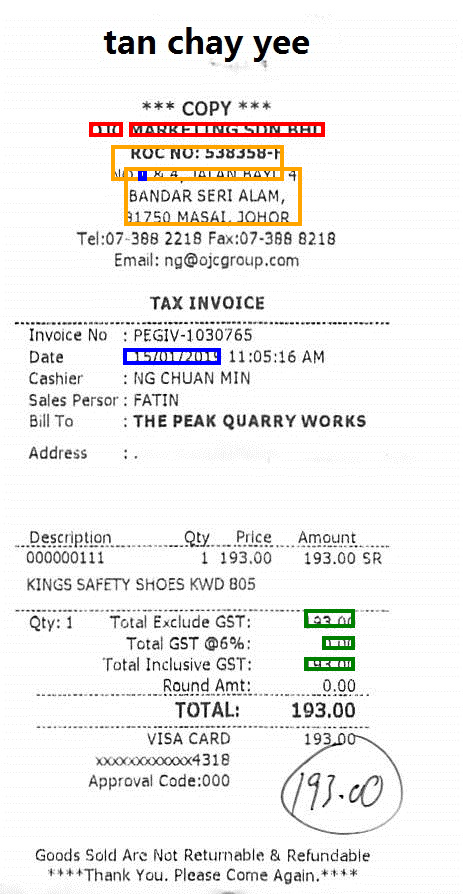

In [ ]:
# --- Run it ---
TEST_IMAGE = "/content/sroie-datasetv2/SROIE2019/test/img/X00016469670.jpg"
# In Colab, just call the function as the last line in your cell
test_visual_inference(TEST_IMAGE, MODEL_DIR)

In [ ]:
# ==========================================
# SAVE MODEL TO GOOGLE DRIVE
# ==========================================

import shutil
import os
# --- Define destination in Drive ---
DRIVE_SAVE_DIR = "/content/drive/MyDrive/layoutlmv3-sroie-model"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

# --- Copy best checkpoint to Drive ---
checkpoint_dir = os.path.abspath(best_checkpoint)

print(f"Copying from: {checkpoint_dir}")
print(f"Copying to  : {DRIVE_SAVE_DIR}")

shutil.copytree(
    checkpoint_dir,
    os.path.join(DRIVE_SAVE_DIR, best_checkpoint),
    dirs_exist_ok=True
)

print("✅ Model saved to Google Drive!")

Copying from: /content/layoutlmv3-sroie-model/checkpoint-189
Copying to  : /content/drive/MyDrive/layoutlmv3-sroie-model
✅ Model saved to Google Drive!
